<a href="https://colab.research.google.com/github/Aulia27-maker/BangunRuang/blob/main/AULIA_FAIQOH_CLUSTERING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Import Library**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

**2. Load Dataset**

In [ ]:
student_dataset = pd.read_csv("/content/drive/MyDrive/student_productivity_distraction_dataset_20000.csv")

In [ ]:
student_dataset.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [ ]:
#melihat ukuran dataset
student_dataset.shape

(20000, 18)

In [ ]:
#Melihat informasi data set
student_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [ ]:
#mengecek missing value
student_dataset.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
sleep_hours,0
phone_usage_hours,0
social_media_hours,0
youtube_hours,0
gaming_hours,0
breaks_per_day,0


**3. Statistik Deskriptif**

In [ ]:
student_dataset.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


**4. membuat salinan dataset**

In [ ]:
student_dataset = student_dataset.copy()

student_dataset

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


**5. Mengecek Data Negatif**

Study Hours

In [ ]:
student_dataset[
    student_dataset.study_hours_per_day < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Sleep Hours

In [ ]:
student_dataset[
    student_dataset.sleep_hours < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Phone Usage Hours

In [ ]:
student_dataset[
    student_dataset.phone_usage_hours < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Social Media Hours

In [ ]:
student_dataset[
    student_dataset.social_media_hours < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


YouTube Hours

In [ ]:
student_dataset[
    student_dataset.youtube_hours < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Gaming Hours

In [ ]:
student_dataset[
    student_dataset.gaming_hours < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Breaks per Day

In [ ]:
student_dataset[
    student_dataset.breaks_per_day < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Coffe Intake

In [ ]:
student_dataset[
    student_dataset.coffee_intake_mg < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Exercise Minutes

In [ ]:
student_dataset[
    student_dataset.exercise_minutes < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Assignments Completed

In [ ]:
student_dataset[
    student_dataset.assignments_completed < 0
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


**6. Mengecek Data Tidak Valid**

Attendance Percentage

In [ ]:
student_dataset[
    (student_dataset.attendance_percentage < 0) |
    (student_dataset.attendance_percentage > 100)
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Final Grade

In [ ]:
student_dataset[
    (student_dataset.final_grade < 0) |
    (student_dataset.final_grade > 100)
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


Productivity Score

In [ ]:
student_dataset[
    (student_dataset.productivity_score < 0) |
    (student_dataset.productivity_score > 100)
]

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score


**7. Membersihkan data tidak valid**

In [ ]:
student_dataset_preprocess = student_dataset.copy()

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.study_hours_per_day >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.sleep_hours >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.phone_usage_hours >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.social_media_hours >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.youtube_hours >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.gaming_hours >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.breaks_per_day >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.coffee_intake_mg >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.exercise_minutes >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    student_dataset_preprocess.assignments_completed >= 0
]

student_dataset_preprocess = student_dataset_preprocess[
    (student_dataset_preprocess.attendance_percentage >= 0) &
    (student_dataset_preprocess.attendance_percentage <= 100)
]

student_dataset_preprocess = student_dataset_preprocess[
    (student_dataset_preprocess.final_grade >= 0) &
    (student_dataset_preprocess.final_grade <= 100)
]

student_dataset_preprocess = student_dataset_preprocess[
    (student_dataset_preprocess.productivity_score >= 0) &
    (student_dataset_preprocess.productivity_score <= 100)
]

student_dataset_preprocess

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


**8. Membuat Variabel Total Distraction Hours**

In [ ]:
student_dataset_preprocess = student_dataset_preprocess.copy()

student_dataset_preprocess['total_distraction_hours'] = (
    student_dataset_preprocess.phone_usage_hours +
    student_dataset_preprocess.social_media_hours +
    student_dataset_preprocess.youtube_hours +
    student_dataset_preprocess.gaming_hours
)

student_dataset_preprocess

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78,13.20
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99,11.85
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60,13.35
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87,22.28
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90,15.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43,22.24
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84,14.88
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56,11.69
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06,17.26


**9. Membbuat Variabel Distraction Ratio**

In [ ]:
student_dataset_preprocess['study_distraction_ratio'] = (
    student_dataset_preprocess.study_hours_per_day /
    (student_dataset_preprocess.total_distraction_hours + 1)
)

student_dataset_preprocess

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours,study_distraction_ratio
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78,13.20,0.306338
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99,11.85,0.477821
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60,13.35,0.347038
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87,22.28,0.137027
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90,15.72,0.458732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43,22.24,0.206971
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84,14.88,0.052267
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56,11.69,0.737589
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06,17.26,0.040526


**10. Memilih Fitur Untuk Clustering**

In [ ]:
feature_columns = [
    'age',
    'study_hours_per_day',
    'sleep_hours',
    'phone_usage_hours',
    'social_media_hours',
    'youtube_hours',
    'gaming_hours',
    'breaks_per_day',
    'coffee_intake_mg',
    'exercise_minutes',
    'assignments_completed',
    'attendance_percentage',
    'stress_level',
    'focus_score',
    'final_grade',
    'productivity_score'
]

X = student_dataset[feature_columns].copy()

X.head()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,23,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,20,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,29,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,27,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,24,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


**11. Visualisasi Data Awal**

Study Hours dan Productivity Score

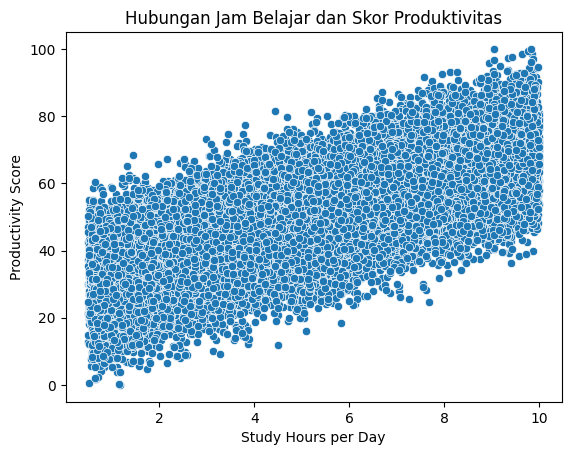

In [ ]:
sb.scatterplot(
    data=student_dataset,
    x='study_hours_per_day',
    y='productivity_score'
)

plt.title("Hubungan Jam Belajar dan Skor Produktivitas")
plt.xlabel("Study Hours per Day")
plt.ylabel("Productivity Score")
plt.show()

Total Distraction dan Productivity Score

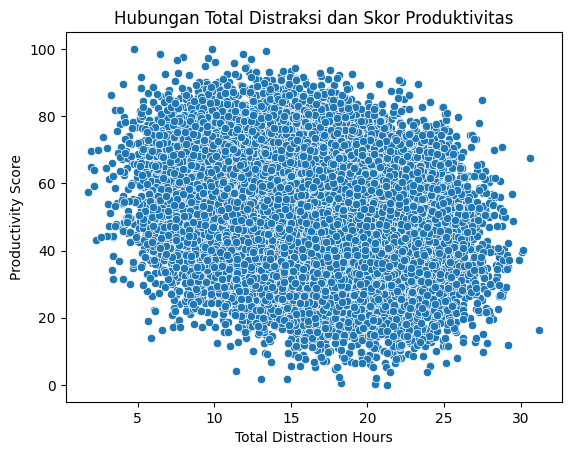

In [ ]:
sb.scatterplot(
    x=student_dataset_preprocess.total_distraction_hours,
    y=student_dataset_preprocess.productivity_score
)
plt.title("Hubungan Total Distraksi dan Skor Produktivitas")
plt.xlabel("Total Distraction Hours")
plt.ylabel("Productivity Score")
plt.show()

Focus Score dan Productivity Score

<Axes: xlabel='focus_score', ylabel='productivity_score'>

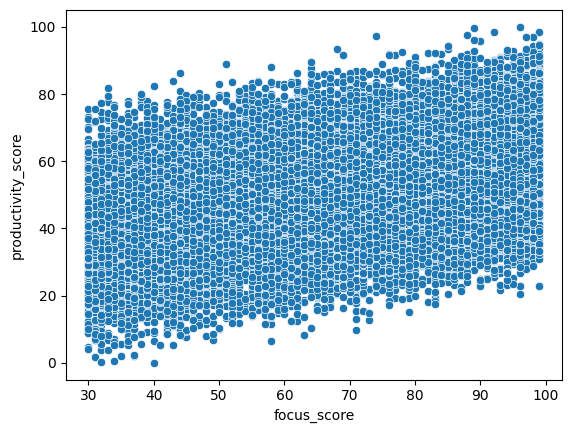

In [ ]:
sb.scatterplot(
    x=X.focus_score,
    y=X.productivity_score
)

**12. Standarisasi Data**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,-0.001984,-0.329794,-1.422748,-0.866429,-0.552539,-0.670711,1.311007,-0.384051,0.677385,1.483694,-1.291791,-0.732163,1.577068,-0.368978,0.671432,-1.019529
1,-0.800962,0.322822,0.030645,-0.232562,-1.081801,0.080833,-0.726205,1.358920,1.067065,-0.914396,0.087204,1.225646,1.577068,-0.765496,-0.541980,-0.074002
2,1.595972,-0.100102,-1.605038,-0.428759,-0.162100,-1.624594,0.993595,-1.629031,1.178403,1.223660,-0.257545,-0.391299,-1.213431,-1.310709,0.923142,-0.844225
3,1.063320,-0.752718,-0.954706,1.149871,-0.023277,1.595484,-0.270285,0.362936,-0.498613,-0.914396,1.466200,-1.692099,0.181818,-0.715931,0.087004,-1.884242
4,0.264342,0.880645,-0.151645,-0.975092,-1.047095,1.427832,1.536082,0.113941,1.296698,1.310338,-0.429919,-1.403543,0.181818,-1.162014,1.149391,0.169062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.796994,-0.162083,0.646490,0.183979,1.269511,-0.127287,1.553395,-0.384051,1.401077,-1.723390,0.259579,-0.359685,-0.864619,1.217096,0.686477,0.637164
19996,-0.268310,-1.613151,-0.999047,0.153794,-0.092688,-0.023227,-0.928195,-1.629031,0.872225,-1.347786,-0.947042,0.236395,1.577068,-0.418543,0.975219,-2.010437
19997,0.530668,1.496801,-1.077875,-0.999239,1.291202,-1.526315,-0.905110,-0.882043,1.136651,-1.694497,0.259579,0.185812,1.228256,0.225800,0.654652,0.956069
19998,-0.268310,-1.645964,-1.023681,-0.935853,0.861719,0.069271,1.166729,-0.135055,0.482545,-1.694497,-0.602294,0.406539,-0.166994,-0.567237,-0.996792,-1.375112


**13. CLUSTERING EXPERIMENT**

KMEANS DENGAN

In [ ]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_model.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
kmeans_model.labels_

array([0, 2, 0, ..., 1, 0, 0], dtype=int32)

In [ ]:
#menambahkan hasil cluster ke Dataset
student_dataset_preprocess['cluster'] = kmeans_model.labels_

student_dataset_preprocess

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,...,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours,study_distraction_ratio,cluster
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,...,111,2,57.21,10,57,81.87,33.78,13.20,0.306338,0
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,...,28,10,91.27,10,49,60.90,48.99,11.85,0.477821,2
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,...,102,8,63.14,2,38,86.22,36.60,13.35,0.347038,0
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,...,28,18,40.51,6,50,71.77,19.87,22.28,0.137027,0
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,...,105,7,45.53,6,41,90.13,52.90,15.72,0.458732,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,...,0,11,63.69,3,89,82.13,60.43,22.24,0.206971,1
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,...,13,4,74.06,10,56,87.12,17.84,14.88,0.052267,0
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,...,1,11,73.18,9,69,81.58,65.56,11.69,0.737589,1
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,...,1,6,77.02,5,53,53.04,28.06,17.26,0.040526,0


<Axes: xlabel='study_hours_per_day', ylabel='productivity_score'>

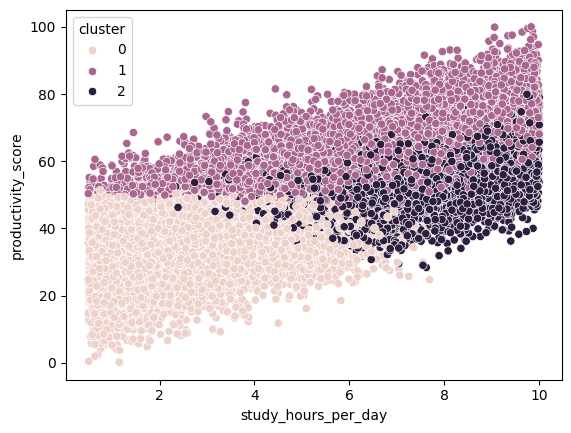

In [ ]:
sb.scatterplot(
    data=student_dataset_preprocess,
    x='study_hours_per_day',
    y='productivity_score',
    hue='cluster'
)

**13. Cari Jumlah Cluster Terbaik**

ELBOW METHOD

In [ ]:
#membuat percobaan jumlah cluster
n_cluster_list = np.arange(2, 11, 1)

clustering_models = [
    KMeans(
        n_clusters=cluster,
        random_state=42,
        n_init=10
    ).fit(X_scaled)
    for cluster in n_cluster_list
]

centroids_list = [
    cluster_model.cluster_centers_
    for cluster_model in clustering_models
]

In [ ]:
#menghitung jarak data ke centroid
distances_to_centroid = [
    cdist(X_scaled, centroid, 'euclidean')
    for centroid in centroids_list
]

cIdx = [
    np.argmin(D, axis=1)
    for D in distances_to_centroid
]

distance_list = [
    np.min(D, axis=1)
    for D in distances_to_centroid
]

avgWithinSS = [
    sum(d) / X_scaled.shape[0]
    for d in distance_list
]

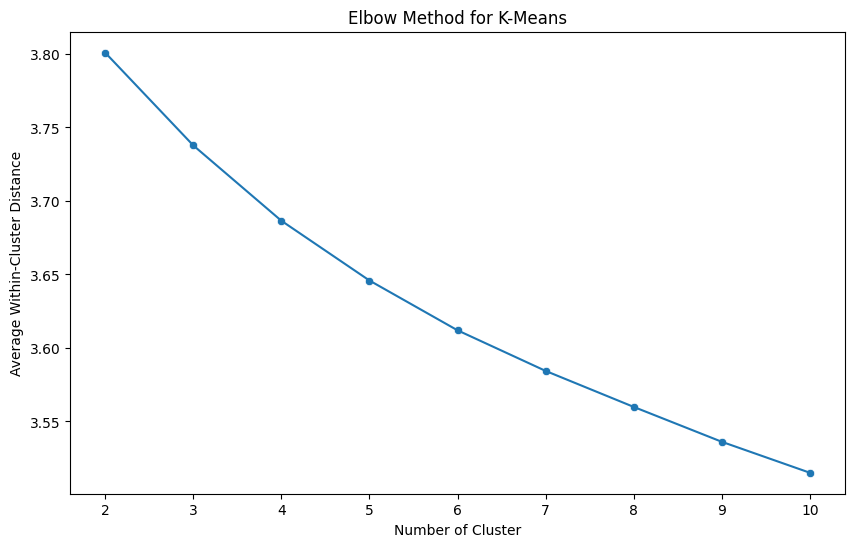

In [ ]:
#grafik Elbow Method
plt.figure(figsize=(10, 6))

sb.lineplot(
    x=n_cluster_list,
    y=avgWithinSS
)

sb.scatterplot(
    x=n_cluster_list,
    y=avgWithinSS
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Cluster")
plt.ylabel("Average Within-Cluster Distance")
plt.show()

In [ ]:
#membuat K-Means Berdasarkan Elbow Method
best_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

best_kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
#menambahkan hasil Cluster ke Data X
X_elbow = X.copy()

X_elbow['cluster'] = best_kmeans.labels_

X_elbow

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,cluster
0,23,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78,0
1,20,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99,2
2,29,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60,0
3,27,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87,0
4,24,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,26,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43,1
19996,22,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84,0
19997,25,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56,1
19998,22,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06,0


<Axes: xlabel='study_hours_per_day', ylabel='productivity_score'>

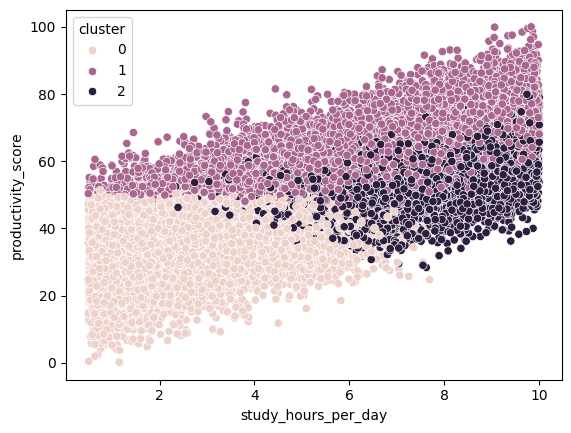

In [ ]:
#Visualisasi Hasil Cluster dati Elbow Method
sb.scatterplot(
    x=X_elbow.study_hours_per_day,
    y=X_elbow.productivity_score,
    hue=X_elbow.cluster
)

SILHOUETTE SCORE

In [ ]:
#membuat sampel data
X_sample = X_scaled.head(200)

In [ ]:
#Menghitung Silhouette Score
silhouette_score_list = []

for cluster in n_cluster_list:
    kmeans = KMeans(
        n_clusters=cluster,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    score = silhouette_score(
        X_scaled,
        kmeans.labels_
    )

    silhouette_score_list.append(score)

n_cluster_experiments = pd.DataFrame({
    'Number of Cluster': n_cluster_list,
    'Silhouette Score': silhouette_score_list
})

n_cluster_experiments

,Number of Cluster,Silhouette Score
0,2,0.079238
1,3,0.054989
2,4,0.049048
3,5,0.047641
4,6,0.045622
5,7,0.046014
6,8,0.043836
7,9,0.043931
8,10,0.043480


In [ ]:
#mengurutkan Silhouette Score
n_cluster_experiments.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Number of Cluster,Silhouette Score
0,2,0.079238
1,3,0.054989
2,4,0.049048
3,5,0.047641
5,7,0.046014
4,6,0.045622
7,9,0.043931
6,8,0.043836
8,10,0.043480


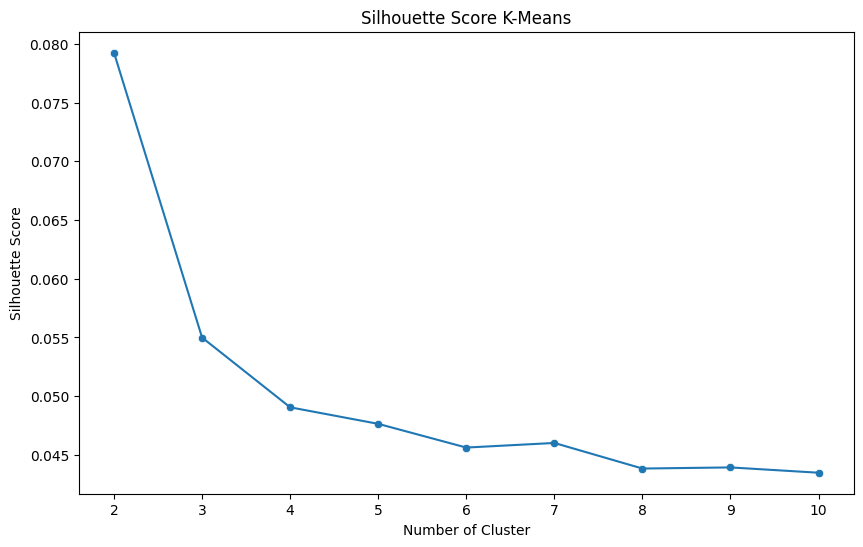

In [ ]:
#Grafik Silhouette Score
plt.figure(figsize=(10, 6))

sb.lineplot(
    x=n_cluster_list,
    y=silhouette_score_list
)

sb.scatterplot(
    x=n_cluster_list,
    y=silhouette_score_list
)

plt.title("Silhouette Score K-Means")
plt.xlabel("Number of Cluster")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
#menentukan jumlah cluster terbaik
best_k = n_cluster_experiments.sort_values(
    by='Silhouette Score',
    ascending=False
).iloc[0]['Number of Cluster']

best_k = int(best_k)

best_k

2

In [ ]:
#K-Means dengan Jumlah Cluster terbaik
best_kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

best_kmeans_model.fit(X_scaled)

student_dataset_preprocess['cluster_kmeans_best'] = best_kmeans_model.labels_

student_dataset_preprocess

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,...,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,total_distraction_hours,study_distraction_ratio,cluster,cluster_kmeans_best
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,...,2,57.21,10,57,81.87,33.78,13.20,0.306338,0,0
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,...,10,91.27,10,49,60.90,48.99,11.85,0.477821,2,0
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,...,8,63.14,2,38,86.22,36.60,13.35,0.347038,0,0
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,...,18,40.51,6,50,71.77,19.87,22.28,0.137027,0,0
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,...,7,45.53,6,41,90.13,52.90,15.72,0.458732,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,...,11,63.69,3,89,82.13,60.43,22.24,0.206971,1,1
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,...,4,74.06,10,56,87.12,17.84,14.88,0.052267,0,0
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,...,11,73.18,9,69,81.58,65.56,11.69,0.737589,1,1
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,...,6,77.02,5,53,53.04,28.06,17.26,0.040526,0,0


<Axes: xlabel='study_hours_per_day', ylabel='productivity_score'>

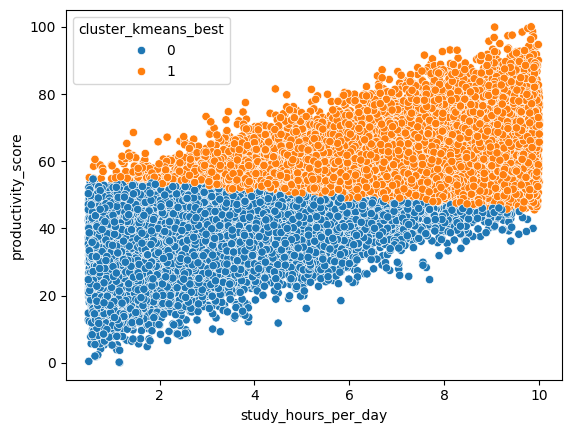

In [ ]:
#visualisasi cluster terbaik
sb.scatterplot(
    data=student_dataset_preprocess,
    x='study_hours_per_day',
    y='productivity_score',
    hue='cluster_kmeans_best'
)

In [ ]:
#Profil Cluster
cluster_profile = student_dataset_preprocess.groupby(
    'cluster_kmeans_best'
)[X.columns].mean()

cluster_profile

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
cluster_kmeans_best,,,,,,,,,,,,,,,,
0,23.067066,3.282751,6.071168,6.905644,3.993086,2.989626,2.976180,7.559558,249.605621,59.420556,9.475041,67.954365,5.832183,59.035613,70.242306,36.948998
1,22.949527,7.170390,6.951749,5.613915,4.013924,2.990713,3.000153,7.525729,249.702090,59.869085,9.512618,71.883921,5.135351,69.699527,70.289827,63.036184


In [ ]:
#melihat anggota setiap cluster
student_dataset_preprocess['cluster_kmeans_best'].value_counts().sort_index()

,count
cluster_kmeans_best,
0,9856
1,10144


AGGLOMERATIVE CLUSTERING

In [ ]:
#Mengambil Sampel Data
X_sample = X_scaled.sample(
    n=1000,
    random_state=42
)

In [ ]:
#membuat modelAgglomerative Clusterint
ward_agglomerative = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

average_agglomerative = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='average'
)

complete_agglomerative = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='complete'
)

single_agglomerative = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='single'
)

In [ ]:
ward_agglomerative.fit(X_sample)

average_agglomerative.fit(X_sample)

complete_agglomerative.fit(X_sample)

single_agglomerative.fit(X_sample)

AgglomerativeClustering(linkage='single')

In [ ]:
#Menghitung Silhouette Score Agglomerative
silhouette_ward = silhouette_score(
    X_sample,
    ward_agglomerative.labels_
)

silhouette_average = silhouette_score(
    X_sample,
    average_agglomerative.labels_
)

silhouette_complete = silhouette_score(
    X_sample,
    complete_agglomerative.labels_
)

silhouette_single = silhouette_score(
    X_sample,
    single_agglomerative.labels_
)

print("Silhouette Score Agglomerative Ward:", silhouette_ward)
print("Silhouette Score Agglomerative Average:", silhouette_average)
print("Silhouette Score Agglomerative Complete:", silhouette_complete)
print("Silhouette Score Agglomerative Single:", silhouette_single)

Silhouette Score Agglomerative Ward: 0.046135795743197136
Silhouette Score Agglomerative Average: 0.1639121599148186
Silhouette Score Agglomerative Complete: 0.05049007362964737
Silhouette Score Agglomerative Single: 0.12717597635587247


Membandingkan K-Means dan Agglomerative

In [ ]:
kmeans_sample = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_sample.fit(X_sample)

silhouette_kmeans = silhouette_score(
    X_sample,
    kmeans_sample.labels_
)

comparison_result = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'Agglomerative Ward',
        'Agglomerative Average',
        'Agglomerative Complete',
        'Agglomerative Single'
    ],
    'Silhouette Score': [
        silhouette_kmeans,
        silhouette_ward,
        silhouette_average,
        silhouette_complete,
        silhouette_single
    ]
})

comparison_result

,Algorithm,Silhouette Score
0,K-Means,0.077210
1,Agglomerative Ward,0.046136
2,Agglomerative Average,0.163912
3,Agglomerative Complete,0.050490
4,Agglomerative Single,0.127176


In [ ]:
#Mengurutkan Hasil Perbandingan
comparison_result.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Algorithm,Silhouette Score
2,Agglomerative Average,0.163912
4,Agglomerative Single,0.127176
0,K-Means,0.077210
3,Agglomerative Complete,0.050490
1,Agglomerative Ward,0.046136


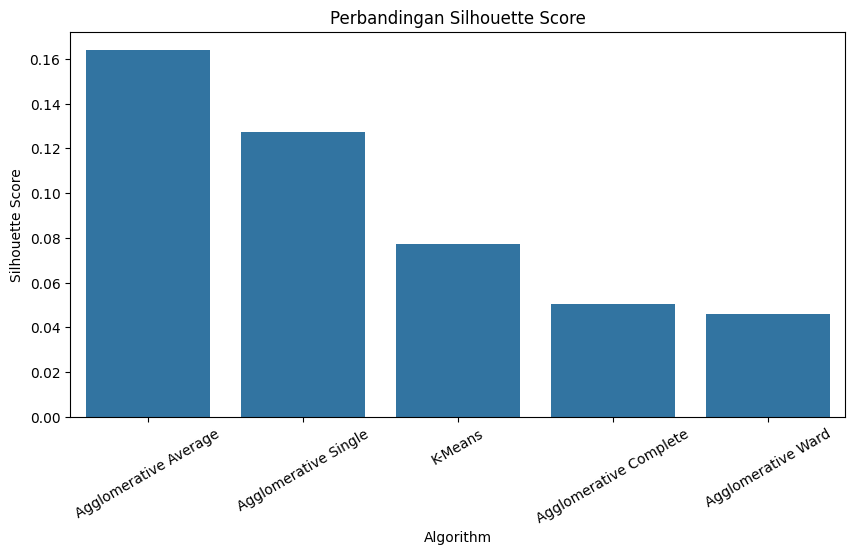

In [ ]:
#grafik perbandingan algoritma
plt.figure(figsize=(10, 5))

sb.barplot(
    data=comparison_result.sort_values(
        by='Silhouette Score',
        ascending=False
    ),
    x='Algorithm',
    y='Silhouette Score'
)

plt.title("Perbandingan Silhouette Score")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=30)
plt.show()

In [ ]:
#menyimpan hasil clustering
student_dataset_preprocess.to_csv(
    "hasil_clustering_student_productivity.csv",
    index=False
)

print("File hasil clustering berhasil disimpan.")

File hasil clustering berhasil disimpan.


**KESIMPULAN**

Berdasarkan hasil clustering pada dataset Student Productivity, data mahasiswa berhasil dikelompokkan berdasarkan kebiasaan belajar, penggunaan teknologi, tingkat distraksi, tingkat stres, fokus, nilai akhir, dan skor produktivitas.

Pada tahap awal, dataset diperiksa terlebih dahulu untuk melihat missing value, data negatif, dan data yang tidak valid. Setelah itu dilakukan preprocessing dan pemilihan fitur numerik yang relevan untuk proses clustering. Data juga distandarkan menggunakan StandardScaler karena algoritma clustering seperti K-Means dan Agglomerative Clustering menggunakan perhitungan jarak.

Berdasarkan hasil Silhouette Score, jumlah cluster terbaik untuk K-Means adalah 2 cluster. Nilai Silhouette Score tertinggi diperoleh pada jumlah cluster 2, yaitu sebesar 0.079238. Hal ini menunjukkan bahwa pembagian data menjadi 2 kelompok memberikan hasil yang paling baik dibandingkan jumlah cluster lainnya pada percobaan 2 sampai 10 cluster.

Hasil K-Means membentuk dua kelompok mahasiswa, yaitu Cluster 0 dan Cluster 1. Cluster 0 berisi 9.856 data mahasiswa, sedangkan Cluster 1 berisi 10.144 data mahasiswa. Jumlah anggota pada kedua cluster cukup seimbang.

Berdasarkan profil cluster, Cluster 0 memiliki rata-rata study_hours_per_day sebesar 3.28, focus_score sebesar 59.04, productivity_score sebesar 36.95, dan stress_level sebesar 5.83. Cluster ini juga memiliki phone_usage_hours yang lebih tinggi, yaitu sebesar 6.91 jam. Oleh karena itu, Cluster 0 dapat dikategorikan sebagai kelompok mahasiswa dengan produktivitas lebih rendah, waktu belajar lebih sedikit, fokus lebih rendah, dan tingkat stres lebih tinggi.

Cluster 1 memiliki rata-rata study_hours_per_day sebesar 7.17, focus_score sebesar 69.70, productivity_score sebesar 63.04, dan stress_level sebesar 5.14. Cluster ini juga memiliki attendance_percentage yang lebih tinggi, yaitu sebesar 71.88. Oleh karena itu, Cluster 1 dapat dikategorikan sebagai kelompok mahasiswa yang lebih produktif, memiliki waktu belajar lebih tinggi, fokus lebih baik, tingkat stres lebih rendah, dan produktivitas lebih tinggi.

Berdasarkan perbandingan algoritma, Agglomerative Clustering dengan linkage average memperoleh Silhouette Score tertinggi, yaitu sebesar 0.163912. Nilai ini lebih tinggi dibandingkan K-Means yang memperoleh Silhouette Score sebesar 0.077210. Dengan demikian, pada dataset ini Agglomerative Clustering dengan linkage average menghasilkan kualitas cluster yang lebih baik dibandingkan K-Means.

Secara keseluruhan, hasil clustering menunjukkan bahwa produktivitas mahasiswa cenderung berkaitan dengan jam belajar, fokus, tingkat stres, dan penggunaan teknologi. Mahasiswa dengan jam belajar dan fokus yang lebih tinggi cenderung memiliki skor produktivitas yang lebih baik, sedangkan mahasiswa dengan waktu belajar rendah, fokus rendah, dan tingkat stres lebih tinggi cenderung memiliki skor produktivitas yang lebih rendah.